## 1. Importing the libraries

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

## 2. Configuration

In [3]:
# Dataset config
DATASET_PATH = "./Classified-Data.csv"
TARGET_COLUMN = "TARGET CLASS"

# Train Test Split config
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Preprocessing config
SCALER = StandardScaler()

# Visualization config
FIGURE_SIZE = (10,10)
ALPHA = 0.6

# Model Configuration
K = 13
KNN_PARAMETERS = {
    "n_neighbors": K,
    "weights": "uniform",
    "metric": "minkowski"
}

## 3. Helper Functions 

In [104]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    print("Accuracy score: ", accuracy_score(y_test, y_pred))

    print("\nROC AUC score: ", roc_auc_score(y_test, y_pred_proba))

    cm = confusion_matrix(y_test, y_pred)
    print("\n Confusion matrix: \n", cm)

    print("\n Classification report: \n", classification_report(y_test, y_pred))

In [113]:
def plot_feature_importance(knn_model, X_test, y_test, feature_names):
    """
    Calculates and plots feature importance for a kNN model using Permutation Importance.
    
    Parameters:
    - knn_model: Your trained KNeighborsClassifier
    - X_test: Your scaled test data (NumPy array or DataFrame)
    - y_test: Your true test labels
    - feature_names: A list of the column names for your features
    """
        
    # n_repeats=10 means it shuffles each column 10 times to get a reliable average
    results = permutation_importance(knn_model, X_test, y_test, scoring='accuracy', 
                                     n_repeats=10, random_state=42)
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance_Mean': results.importances_mean,
        'Importance_Std': results.importances_std
    })
    
    importance_df = importance_df.sort_values(by='Importance_Mean', ascending=False)
    
    plt.figure(figsize=FIGURE_SIZE)
    
    sns.barplot(
        x='Importance_Mean', 
        y='Feature', 
        data=importance_df, 
        hue='Feature',
        palette='viridis',
        legend=False
    )
    
    plt.title('kNN Feature Importance (via Permutation)', fontsize=14, pad=15)
    plt.xlabel('Decrease in Accuracy when Feature is Shuffled', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=ALPHA)
    
    plt.tight_layout()
    plt.show()

In [114]:
def plot_roc_curve(model, X_test, y_test):
    y_scores = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=FIGURE_SIZE)

    plt.plot(fpr, tpr, label='Model ROC Curve (AUC = %0.2f)' % roc_auc)
    plt.plot([0,1], [0,1], linestyle='--')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=ALPHA)
    plt.show()

In [40]:
def plot_correlation_heatmap(df, numeric_col):
    corr = df[numeric_col].corr()

    plt.figure(figsize=FIGURE_SIZE)

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm"
    )

    plt.title("Heatmap for correlation analysis")
    plt.show()

In [ ]:
def plot_score_for_k(score):
    plt.figure(figsize=FIGURE_SIZE)
    
    plt.plot(range(1, len(score) + 1), score, marker="x")
        
    plt.xlabel("Number of neighbors (K)")
    plt.ylabel("Error Rate")
    plt.title("Elbow Method: Error Rate for multiple K values")

    plt.grid(True)
    plt.show()

In [95]:
def calculate_error_rate_score(X_train, X_test, y_train, y_test):
    error_rate = []

    for i in range(1,40):
    
        knn = KNeighborsClassifier(n_neighbors=i)
        knn.fit(X_train,y_train)
        pred_i = knn.predict(X_test)
        error_rate.append(np.mean(pred_i != y_test))

    plot_score_for_k(error_rate)

In [118]:
def plot_calibration_curve(model, X_test, y_test, n_bins=10):
    """
    Plots the Calibration Curve (Actual vs Predicted Probabilities) for a Classifier.
    Use this for models like kNN, XGBoost, Logistic Regression, etc.
    """
    y_probs = model.predict_proba(X_test)[:, 1]
    
    prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=n_bins, strategy='uniform')
    
    plt.figure(figsize=(8, 6))
    
    plt.plot([0, 1], [0, 1], linestyle='--', color='darkgrey', label='Perfectly Calibrated')
    
    plt.plot(prob_pred, prob_true, marker='o', color='#1f77b4', lw=2, label='Model Calibration')
    
    plt.xlabel('Mean Predicted Probability', fontsize=12)
    plt.ylabel('Fraction of Actual Positives', fontsize=12)
    plt.title('Calibration Curve (Reliability Diagram)', fontsize=14, pad=15)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

In [ ]:
def display_prediction_example(model, prediction_example):
    for example_name, example_data in prediction_example.items():
        prediction = model.predict(example_data.values)

        print(f"\nScenario : {example_name}")
        print("-" * 20)
        print(example_data)

        print(f"\nPrediction (Target Class): {prediction[0]}")

## 4. Loading the dataset

In [44]:
df = pd.read_csv(DATASET_PATH)

## 5. Understanding the dataset / Dataset overview

In [45]:
df.shape

(1000, 11)

In [46]:
df.columns

Index(['WTT', 'PTI', 'EQW', 'SBI', 'LQE', 'QWG', 'FDJ', 'PJF', 'HQE', 'NXJ',
       'TARGET CLASS'],
      dtype='str')

In [47]:
df.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


In [48]:
df.isnull().sum()

WTT             0
PTI             0
EQW             0
SBI             0
LQE             0
QWG             0
FDJ             0
PJF             0
HQE             0
NXJ             0
TARGET CLASS    0
dtype: int64

In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   WTT           1000 non-null   float64
 1   PTI           1000 non-null   float64
 2   EQW           1000 non-null   float64
 3   SBI           1000 non-null   float64
 4   LQE           1000 non-null   float64
 5   QWG           1000 non-null   float64
 6   FDJ           1000 non-null   float64
 7   PJF           1000 non-null   float64
 8   HQE           1000 non-null   float64
 9   NXJ           1000 non-null   float64
 10  TARGET CLASS  1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB


In [51]:
df.describe()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,0.949682,1.114303,0.834127,0.682099,1.032336,0.943534,0.963422,1.071960,1.158251,1.362725,0.50000
std,0.289635,0.257085,0.291554,0.229645,0.243413,0.256121,0.255118,0.288982,0.293738,0.204225,0.50025
min,0.174412,0.441398,0.170924,0.045027,0.315307,0.262389,0.295228,0.299476,0.365157,0.639693,0.00000
25%,0.742358,0.942071,0.615451,0.515010,0.870855,0.761064,0.784407,0.866306,0.934340,1.222623,0.00000
50%,0.940475,1.118486,0.813264,0.676835,1.035824,0.941502,0.945333,1.065500,1.165556,1.375368,0.50000
75%,1.163295,1.307904,1.028340,0.834317,1.198270,1.123060,1.134852,1.283156,1.383173,1.504832,1.00000
max,1.721779,1.833757,1.722725,1.634884,1.650050,1.666902,1.713342,1.785420,1.885690,1.893950,1.00000


In [52]:
df["TARGET CLASS"].value_counts()

TARGET CLASS
1    500
0    500
Name: count, dtype: int64

The target column is exactly balanced, this may indicate the data is synthetically generated based on the balance and the df.describe() data output range

## 6. Defining the feature list

In [53]:
NUMERICAL_COLUMN = df.select_dtypes(include='number').columns.to_list()

## 7. Outlier Analysis

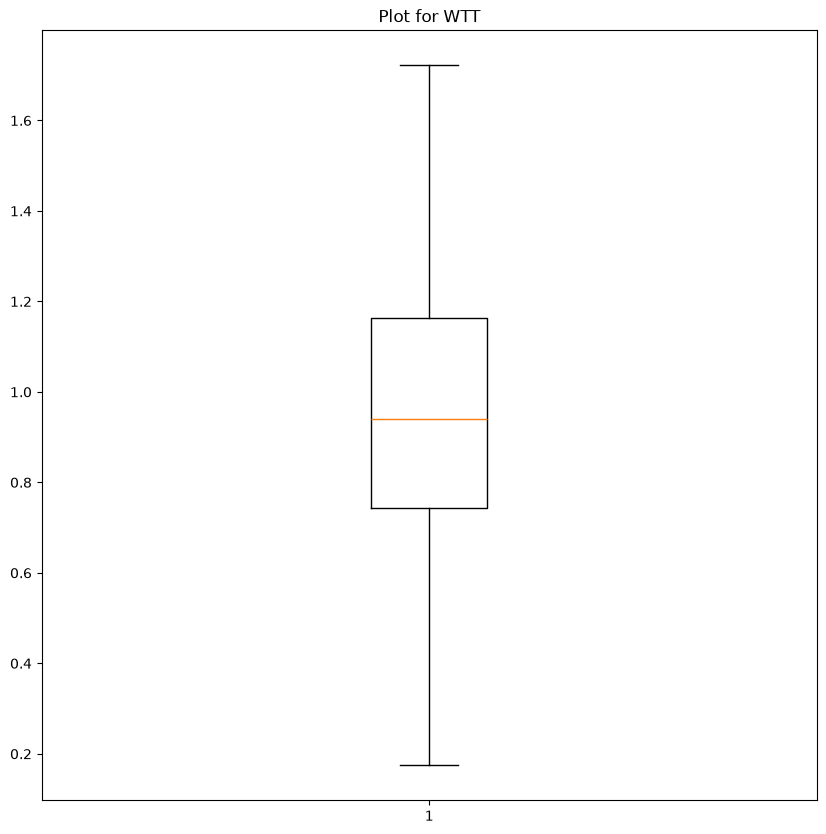

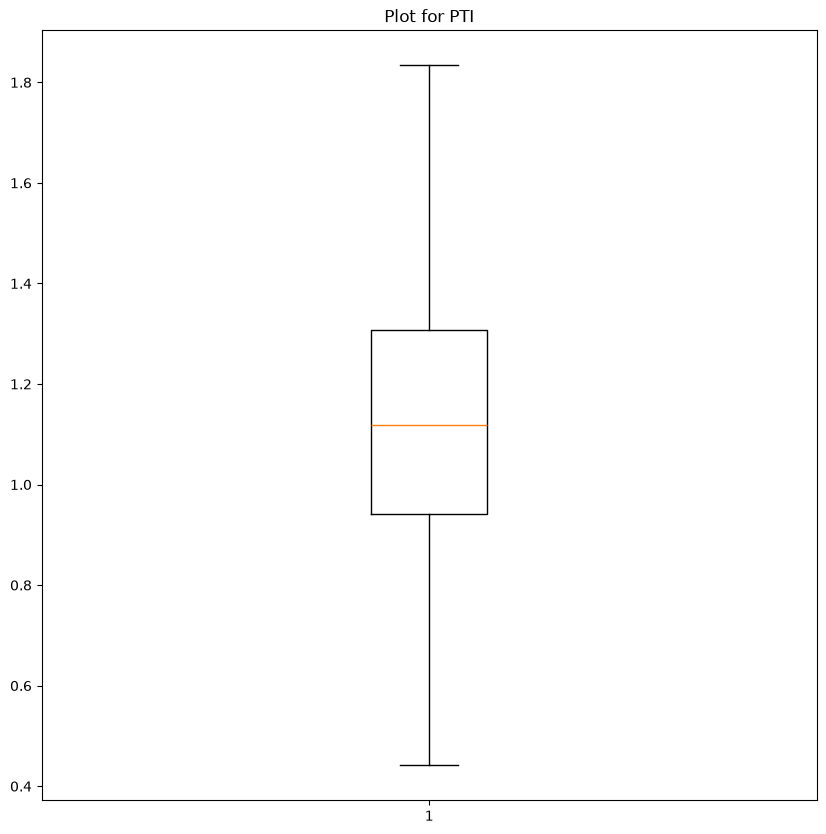

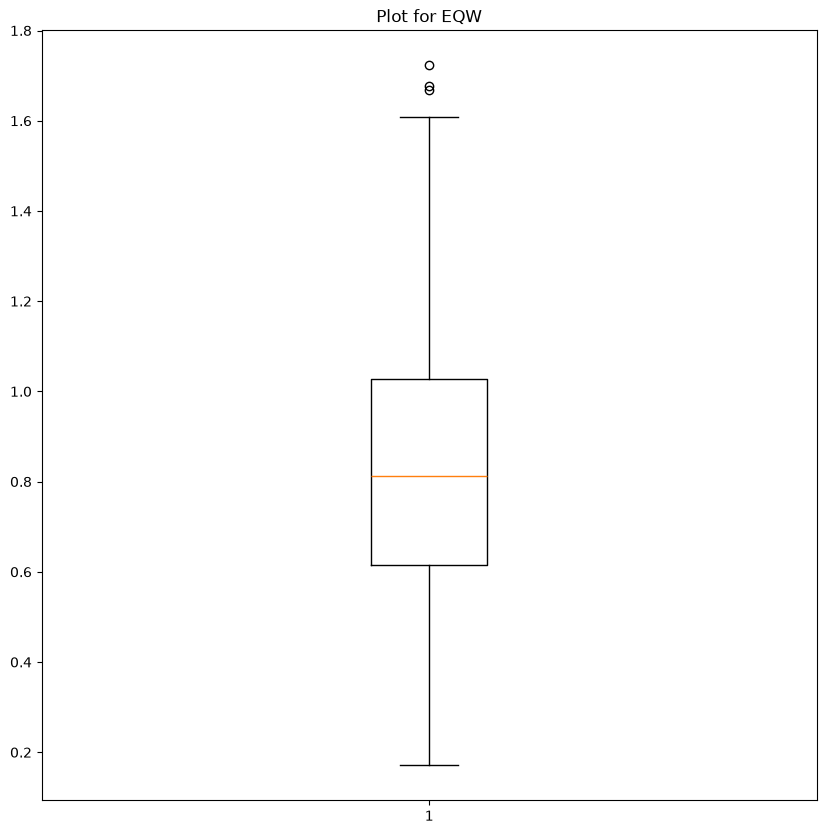

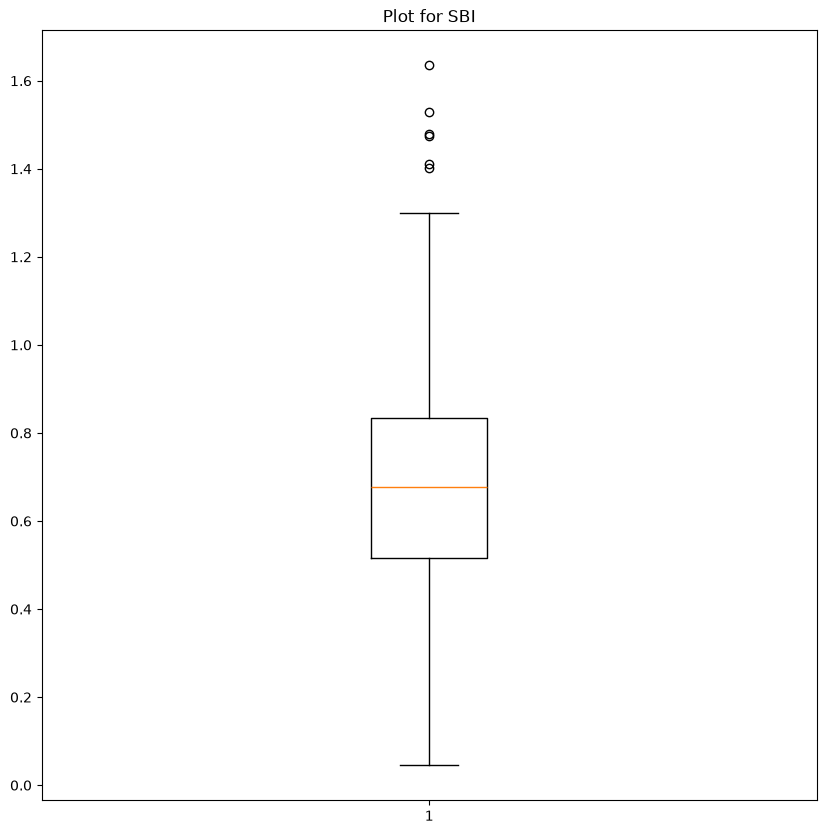

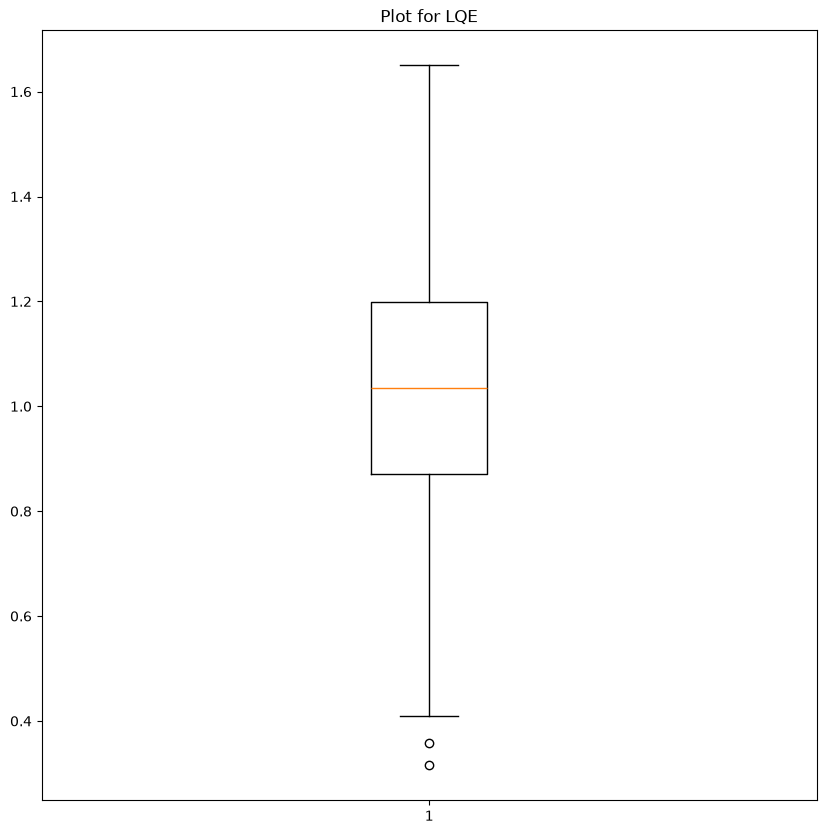

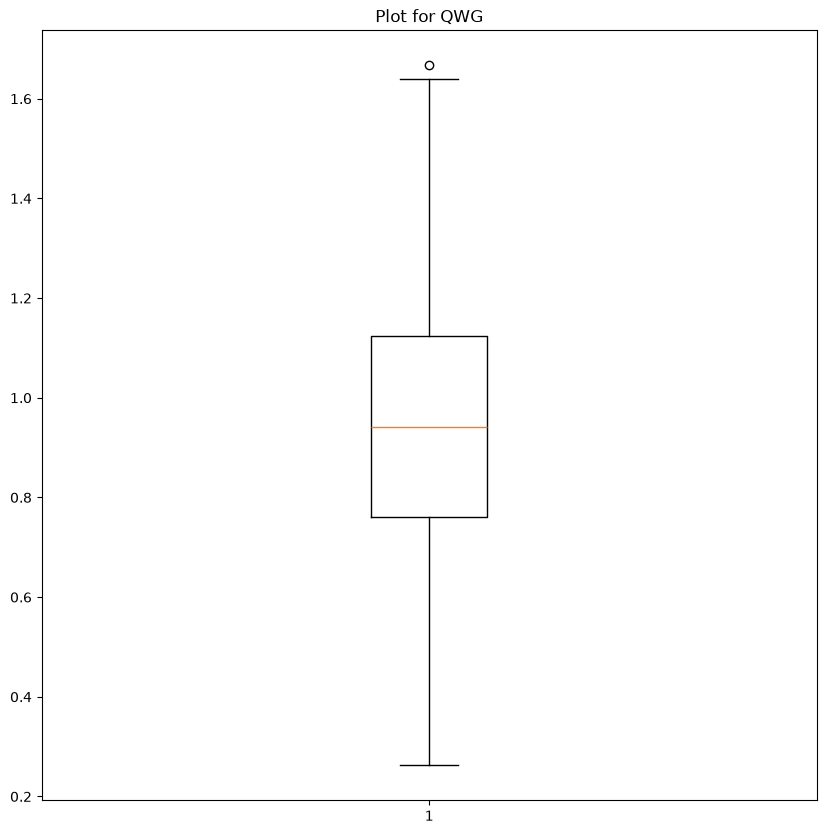

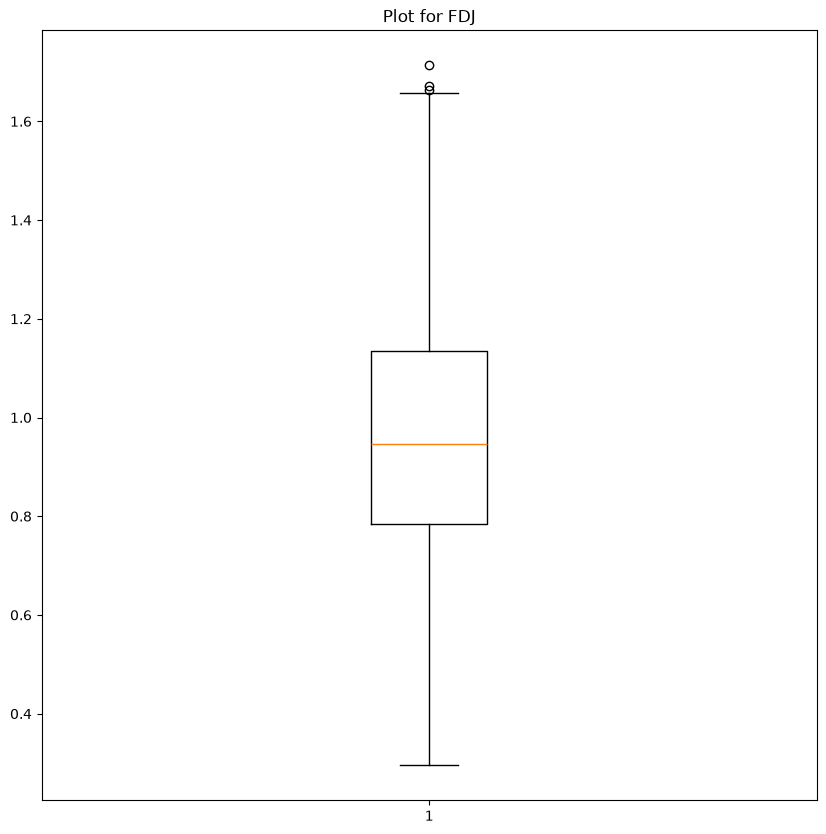

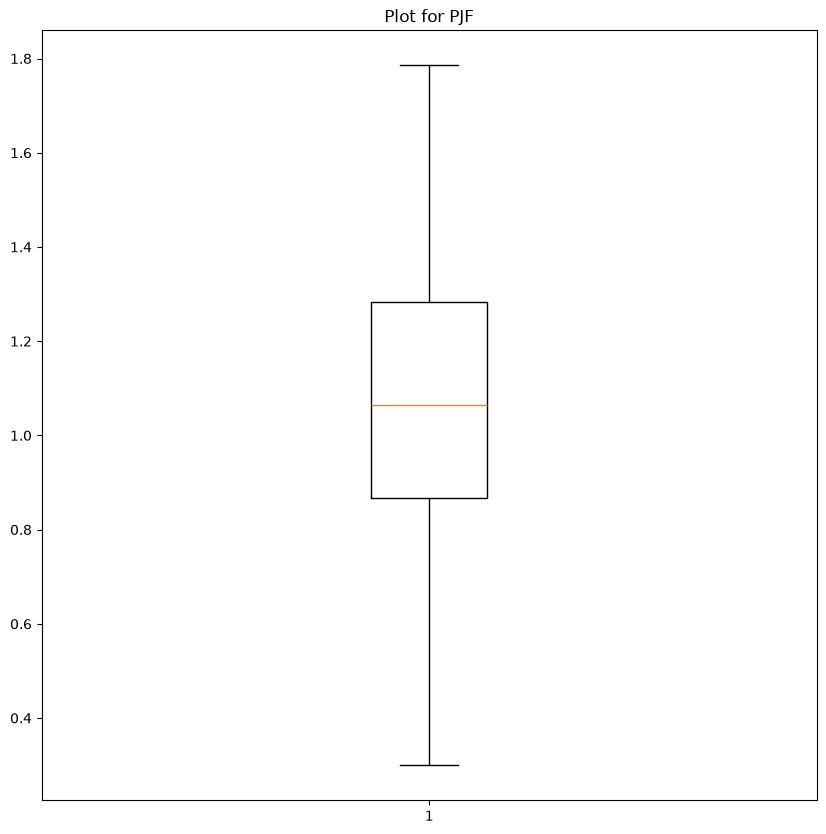

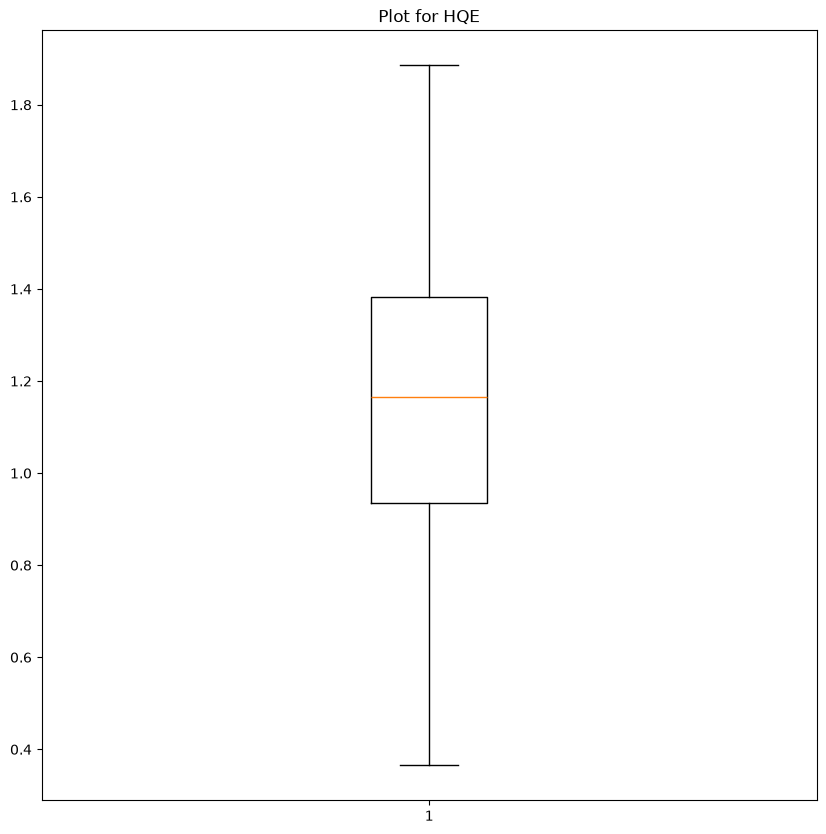

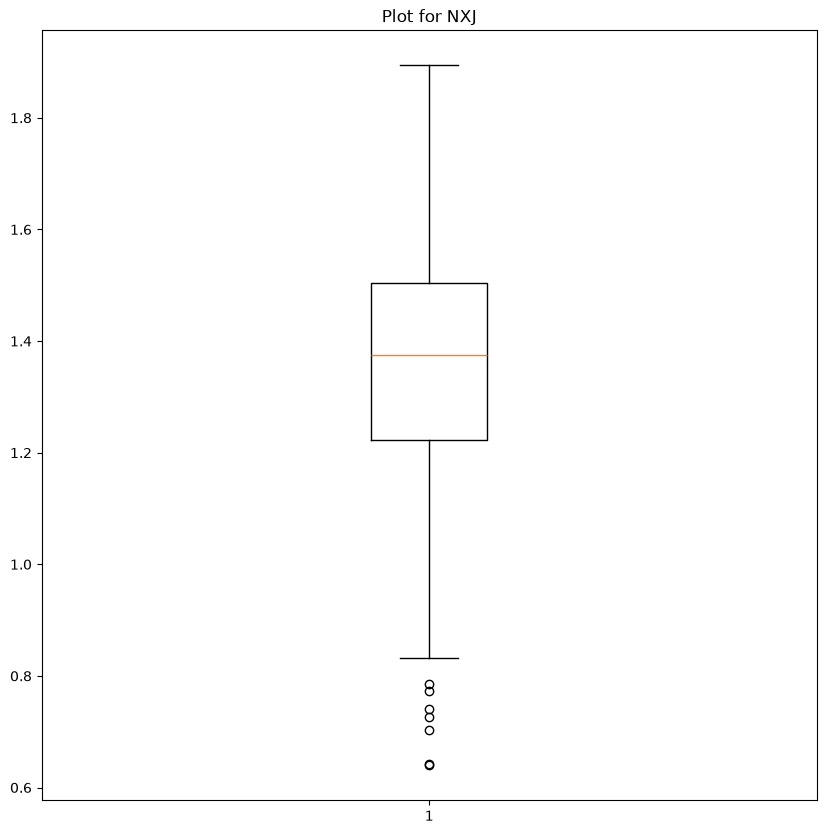

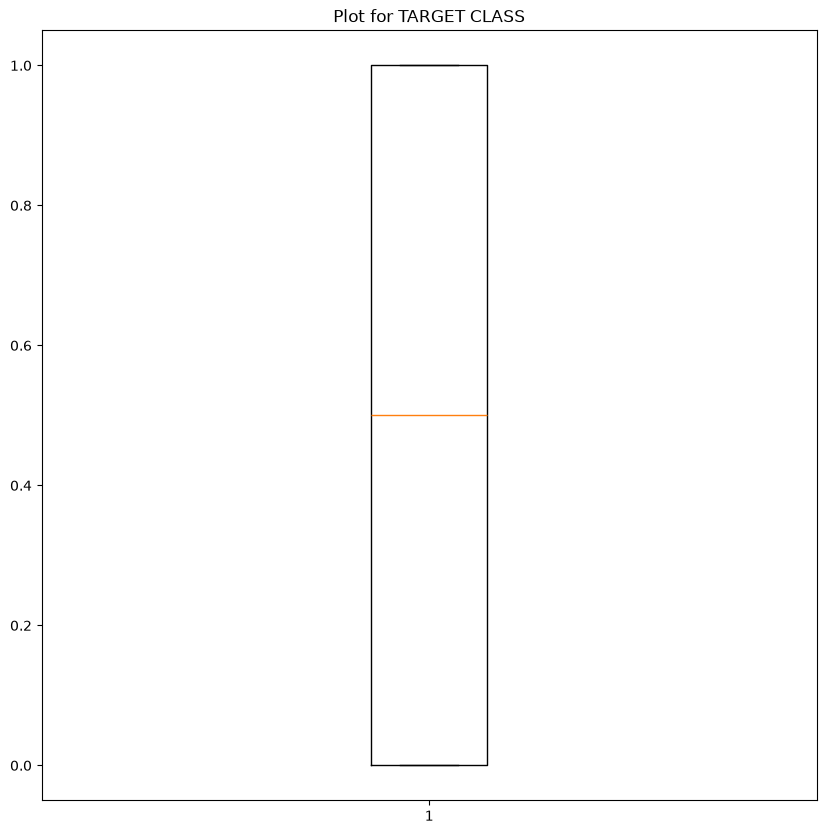

In [54]:
for col in NUMERICAL_COLUMN:
    plt.figure(figsize=FIGURE_SIZE)
    plt.boxplot(x=df[col])
    plt.title(f"Plot for {col}")
    plt.show()

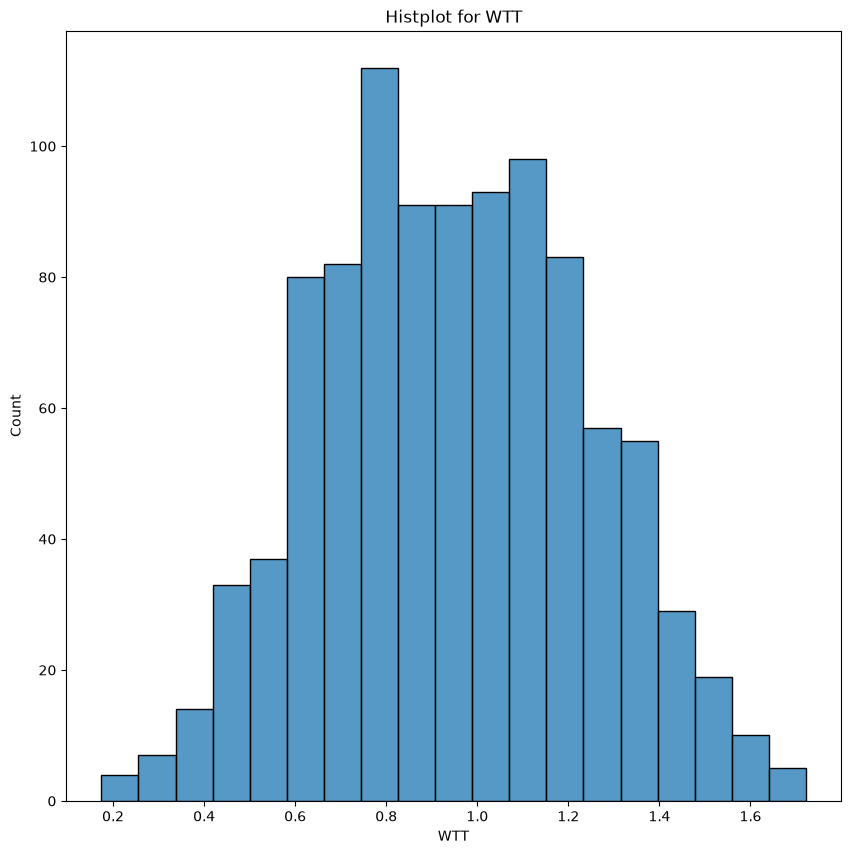

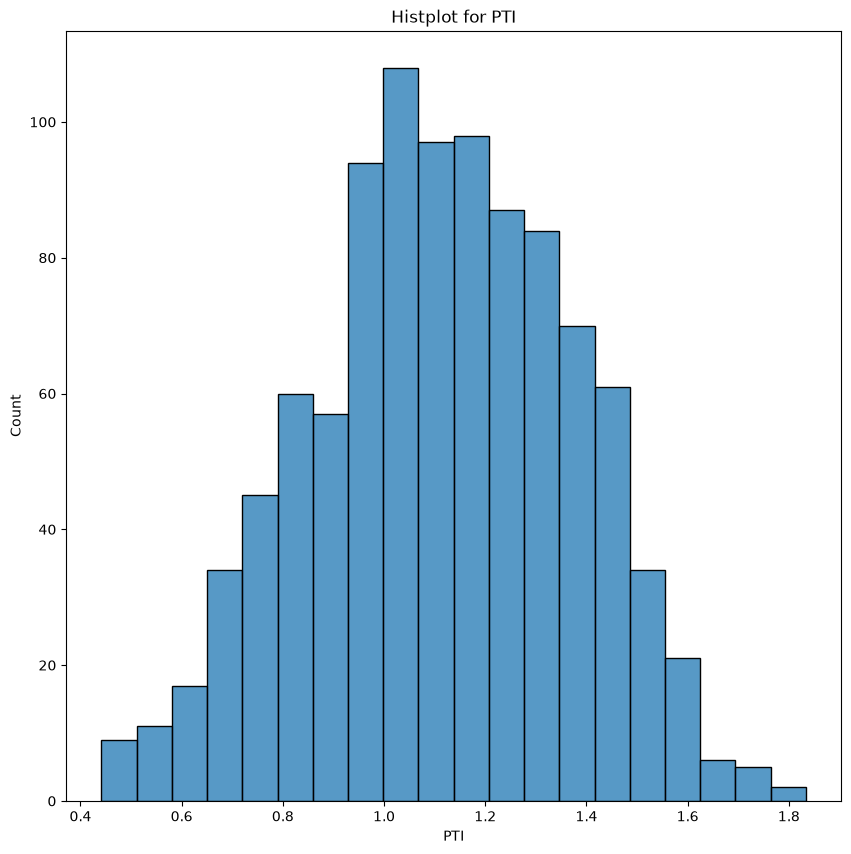

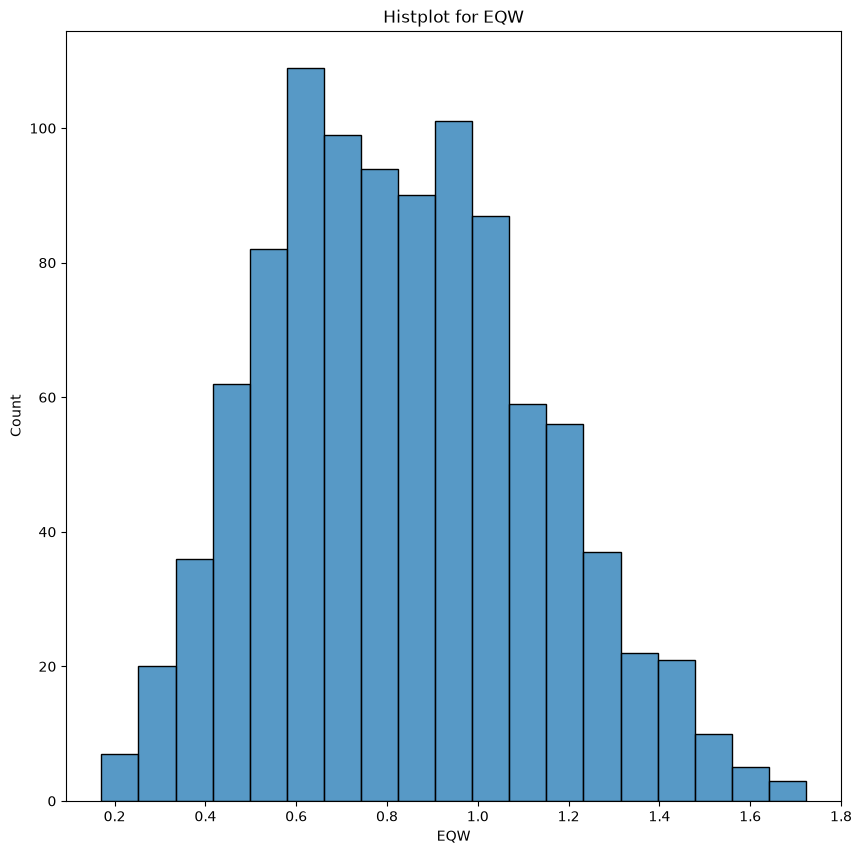

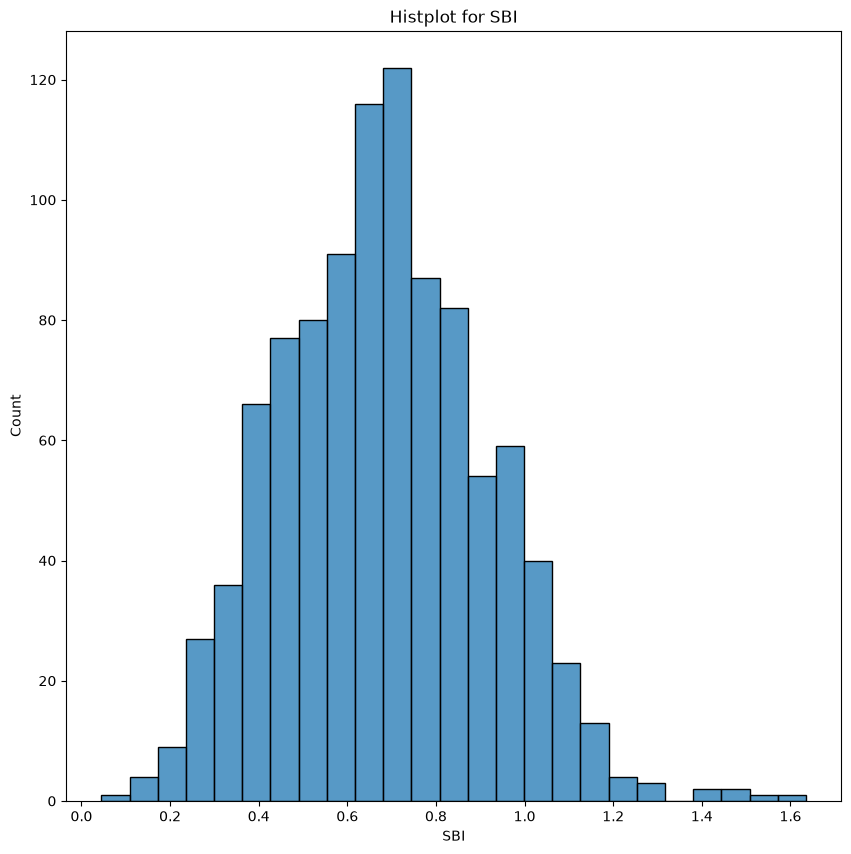

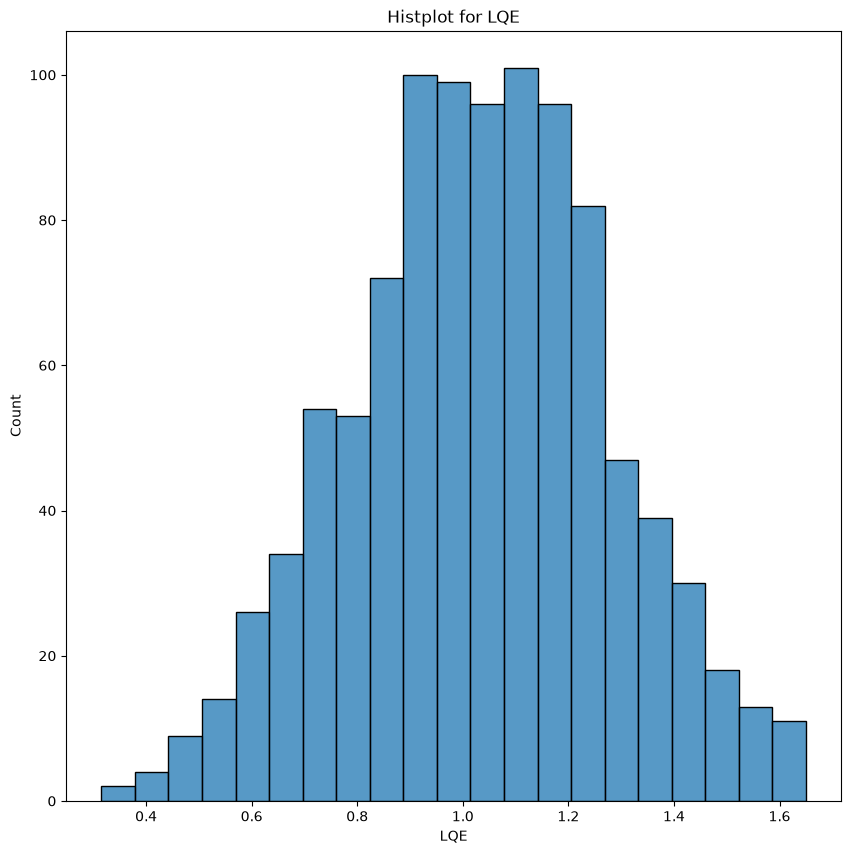

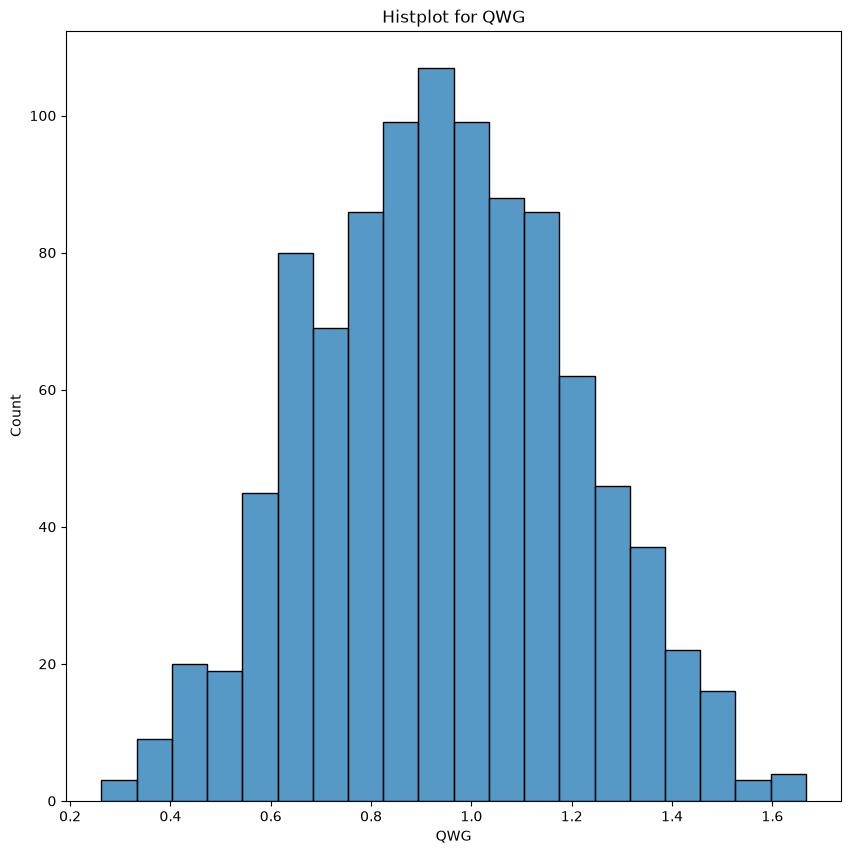

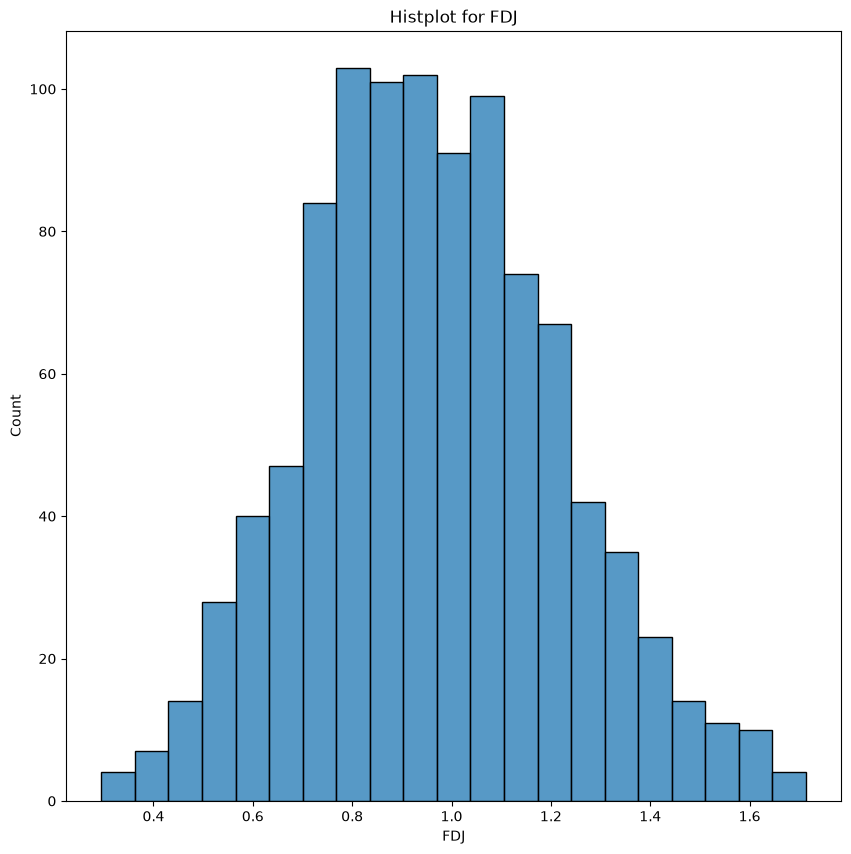

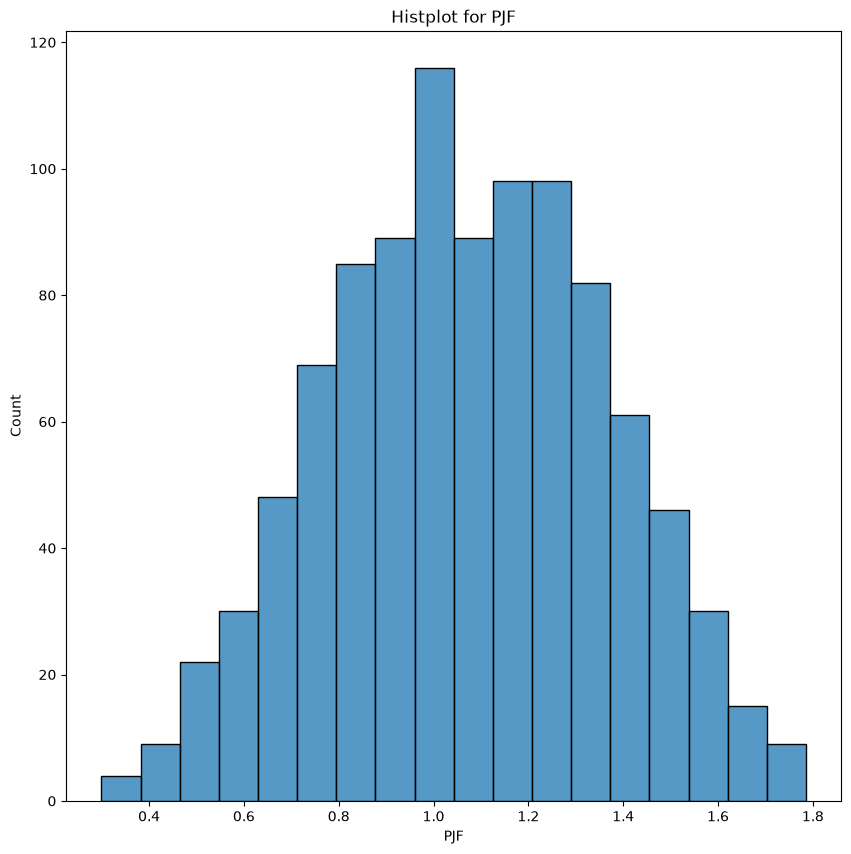

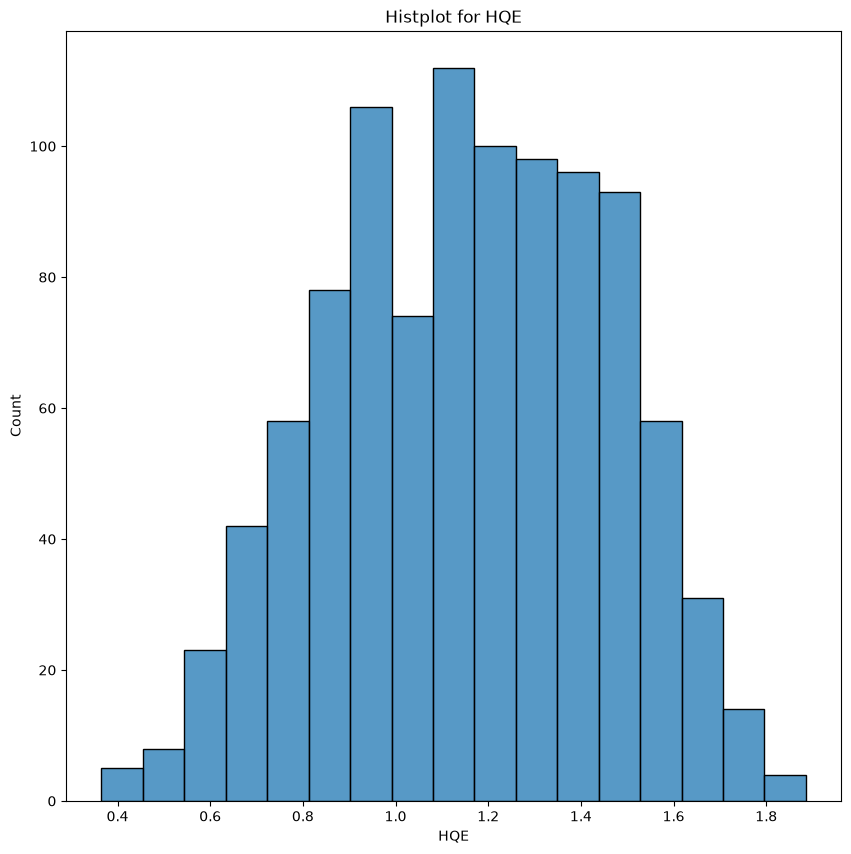

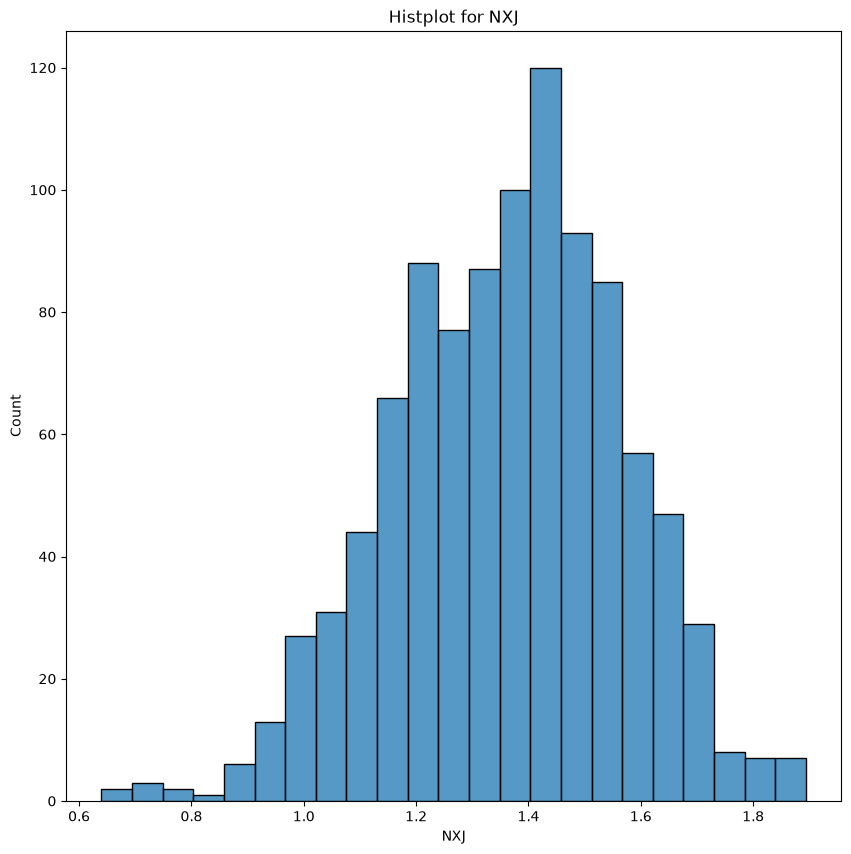

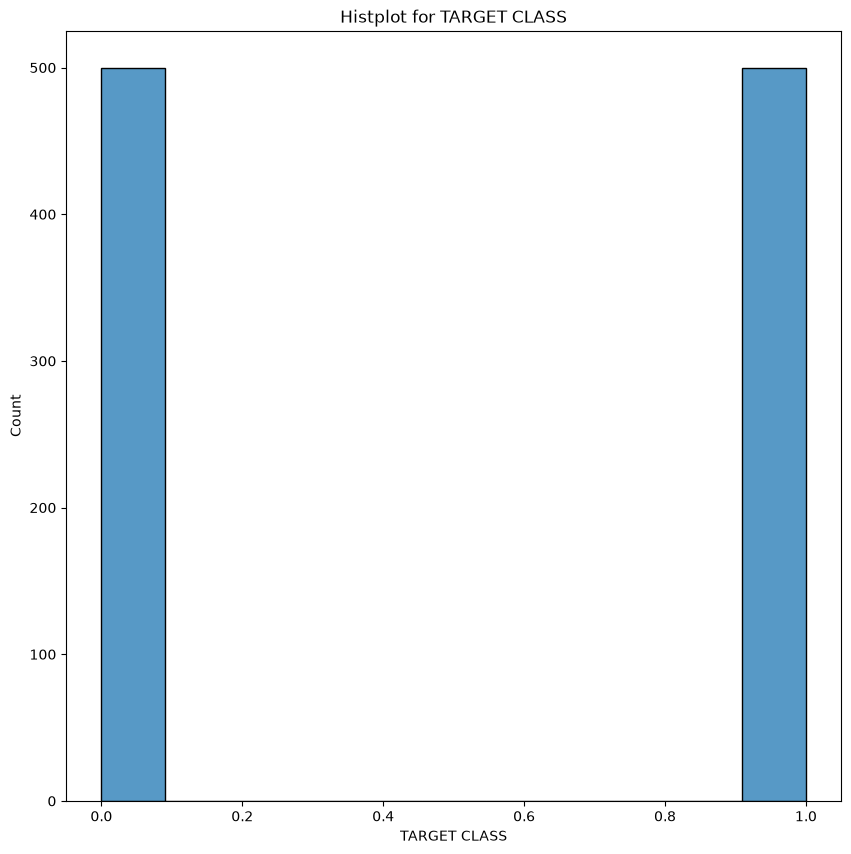

In [55]:
for col in NUMERICAL_COLUMN:
    plt.figure(figsize=FIGURE_SIZE)
    sns.histplot(df[col])
    plt.title(f"Histplot for {col}")
    plt.show()

The distribution is skewed and there are visible outliers so using IQR method to determine the numbers of outliers and do proper analysis

In [56]:
iqr_counts = {}

for col in NUMERICAL_COLUMN:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit, upper_limit = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    iqr_counts[col] = int(((df[col] < lower_limit) | (df[col] > upper_limit)).sum())

pd.DataFrame({ "IQR counts": iqr_counts })

,IQR counts
WTT,0
PTI,0
EQW,3
SBI,6
LQE,2
QWG,1
FDJ,3
PJF,0
HQE,0
NXJ,7


There are very few outliers, so keeping them as it is so that the model also learns from the edge cases.

## 8. Correlation analysis

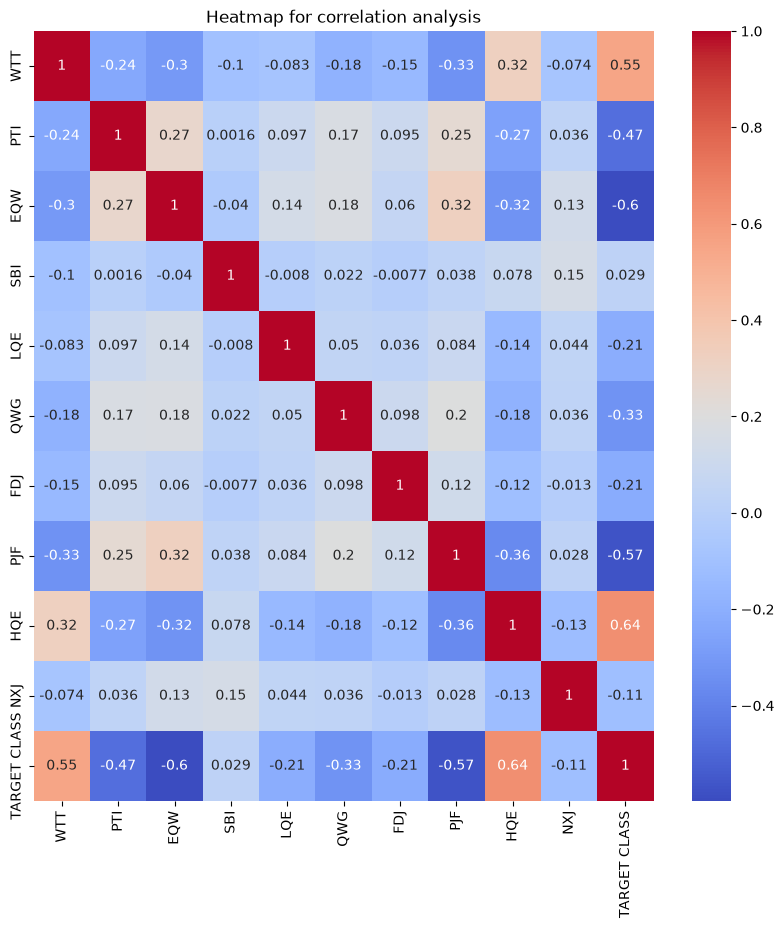

In [57]:
plot_correlation_heatmap(df, NUMERICAL_COLUMN)

There are 4 somewhat relevant relations in the correlation analysis. Which are as follows, other than that there are no relevant relations suggesting the dataset is moreover synthetically generated. The somewhat relations are as follows:
- Target vs WTT (Positive)
- Target vs HQE (Positive)
- Target vs EQW (Negative)
- Target vs PJF (Negative)

#### Preprocessing decisions

✓ Will apply scaling

Reason:
the model being used is a distance based classification algorithm so scaling is preferred to make the predictions better

## 9. Preparing the data for model training

In [58]:
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

In [60]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 10)
(200, 10)
(800,)
(200,)


## 10. Scaling the split data

In [62]:
X_train_scaled = SCALER.fit_transform(X_train)

In [63]:
X_test_scaled = SCALER.transform(X_test)

## 11. Finding out the optimal value of K using error rate

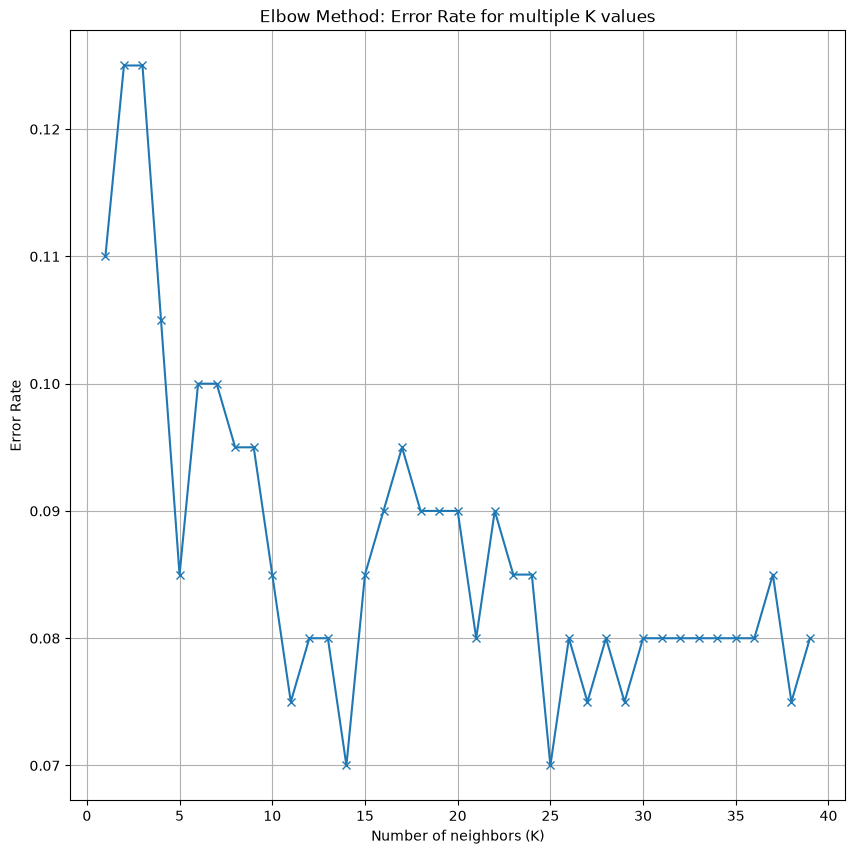

In [96]:
calculate_error_rate_score(X_train_scaled, X_test_scaled, y_train, y_test)

## 12. Fitting the model on the data for the value of k = 13

In [101]:
knn_model = KNeighborsClassifier(**KNN_PARAMETERS)

In [102]:
knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",13
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## 13. Evaluating the model metrics

In [105]:
evaluate_model(knn_model, X_test_scaled, y_test)

Accuracy score:  0.92

ROC AUC score:  0.9837

 Confusion matrix: 
 [[91  9]
 [ 7 93]]

 Classification report: 
               precision    recall  f1-score   support

           0       0.93      0.91      0.92       100
           1       0.91      0.93      0.92       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



## 14. Plot for feature importance

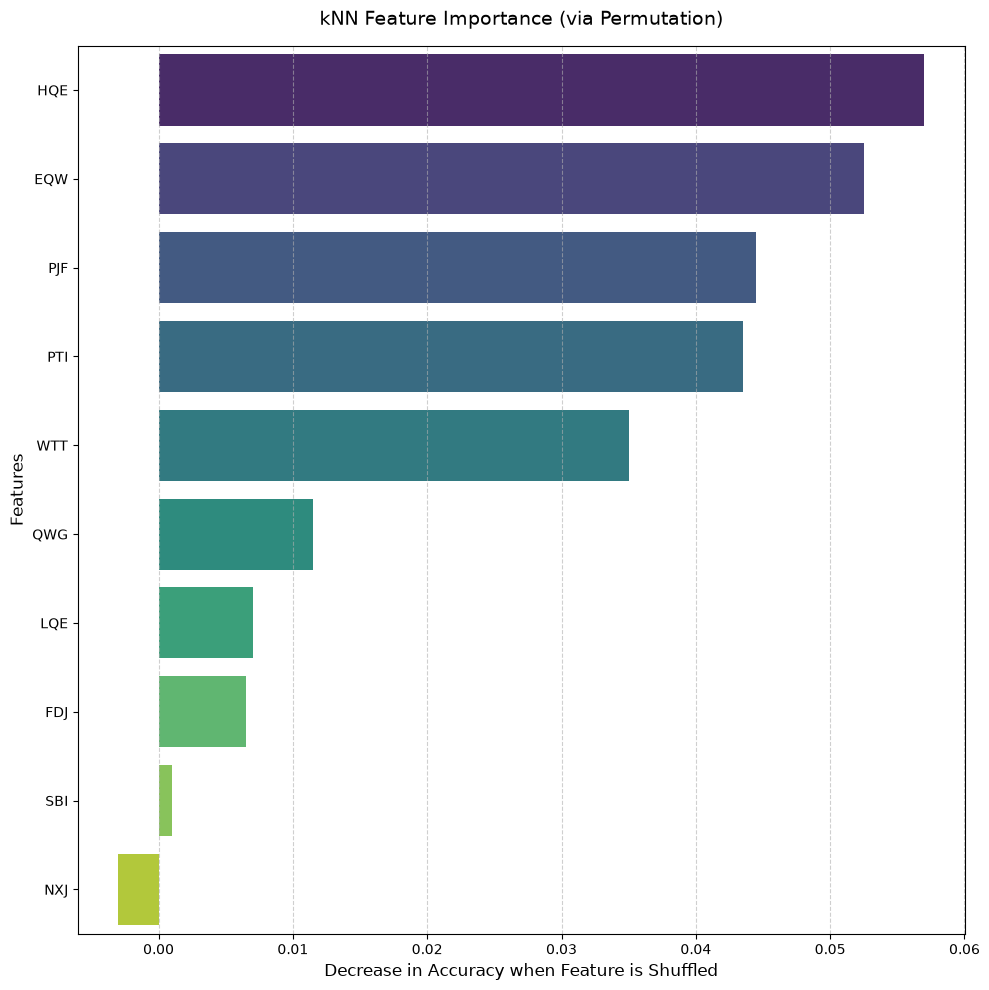

In [109]:
plot_feature_importance(knn_model, X_test_scaled, y_test, X_train.columns)

## 15. Visualization of the ROC curve

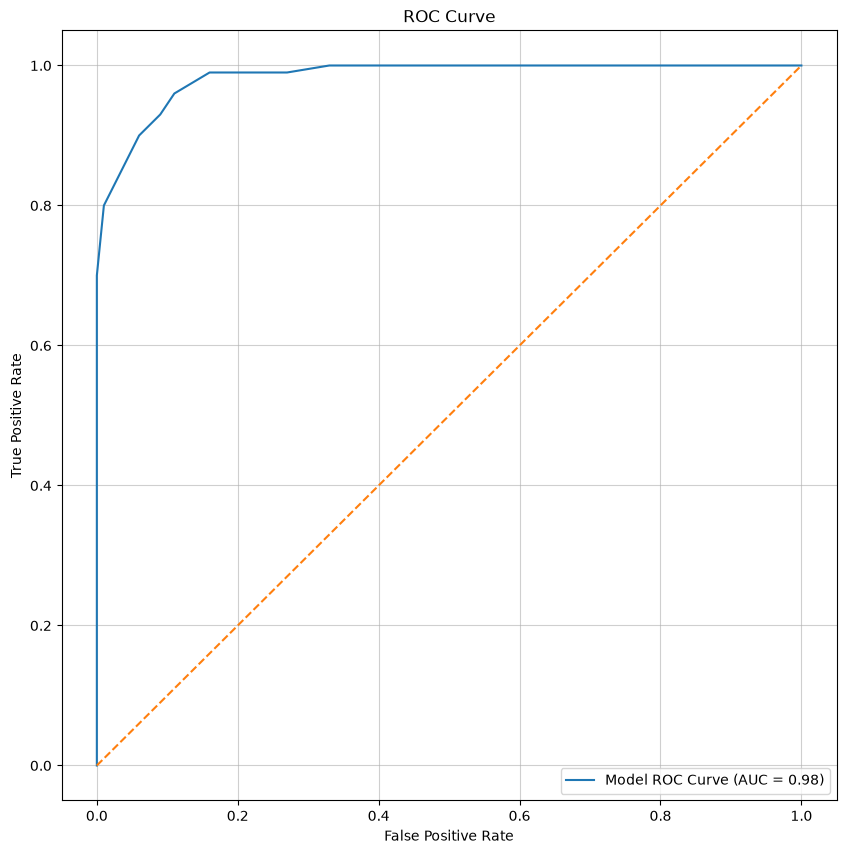

In [115]:
plot_roc_curve(knn_model, X_test_scaled, y_test)

## 16. Visualization of the calibration curve

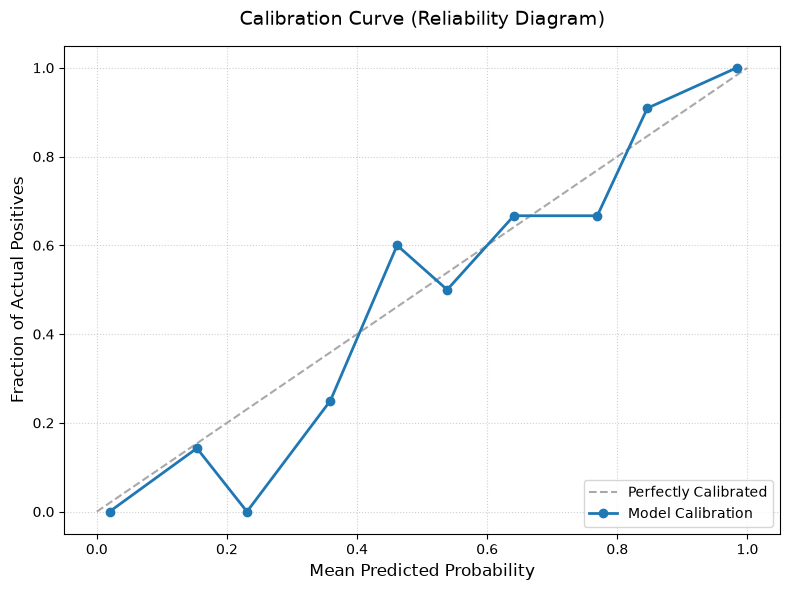

In [119]:
plot_calibration_curve(knn_model, X_test_scaled, y_test)

## 17. Checking the model output predictions

In [124]:
prediction_example = {
    "low_profile": pd.DataFrame([{
        'WTT': 0.74, 
        'PTI': 0.94, 
        'EQW': 0.61, 
        'SBI': 0.51, 
        'LQE': 0.87, 
        'QWG': 0.76, 
        'FDJ': 0.78, 
        'PJF': 0.86, 
        'HQE': 0.93, 
        'NXJ': 1.22
    }]),

    "high_profile": pd.DataFrame([{
        'WTT': 1.16, 
        'PTI': 1.30, 
        'EQW': 1.02, 
        'SBI': 0.83, 
        'LQE': 1.19, 
        'QWG': 1.12, 
        'FDJ': 1.13, 
        'PJF': 1.28, 
        'HQE': 1.38, 
        'NXJ': 1.50
    }])
}

In [ ]:
display_prediction_example(knn_model, prediction_example)


Scenario : low_profile
--------------------
    WTT   PTI   EQW   SBI   LQE   QWG   FDJ   PJF   HQE   NXJ
0  0.74  0.94  0.61  0.51  0.87  0.76  0.78  0.86  0.93  1.22

Prediction (Target Class): 1

Scenario : high_profile
--------------------
    WTT  PTI   EQW   SBI   LQE   QWG   FDJ   PJF   HQE  NXJ
0  1.16  1.3  1.02  0.83  1.19  1.12  1.13  1.28  1.38  1.5

Prediction (Target Class): 0
